# 02 - Cleaning & Preprocessing
**Goal:** Take the merged daily DataFrame from notebook 01 and produce a fully analysis-ready dataset with:
- Outlier detection & treatment
- Feature engineering (rolling sentiment, PnL bins, leverage proxy, etc.)
- Per-account profiling (smart money vs noise)
- Final quality checks before EDA

**Input :** `data/processed/merged_daily.csv`  
**Output:** `data/processed/analysis_ready.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

In [2]:
PROCESSED_DIR = '../data/processed/'
INPUT_FILE    = os.path.join(PROCESSED_DIR, 'merged_daily.csv')
OUTPUT_FILE   = os.path.join(PROCESSED_DIR, 'analysis_ready.csv')

In [3]:
df = pd.read_csv(INPUT_FILE, parse_dates=['date'])

# Restore ordered categorical for fg_label
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
df['fg_label'] = pd.Categorical(df['fg_label'], categories=sentiment_order, ordered=True)

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
df.head()

Shape   : (2341, 14)
Columns : ['account', 'date', 'total_pnl', 'total_volume', 'total_fee', 'trade_count', 'buy_count', 'sell_count', 'avg_exec_price', 'coins_traded', 'net_pnl', 'buy_ratio', 'fg_value', 'fg_label']


,account,date,total_pnl,total_volume,total_fee,trade_count,buy_count,sell_count,avg_exec_price,coins_traded,net_pnl,buy_ratio,fg_value,fg_label
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,900880.13,167.796055,177,0,177,3204.461017,1,-167.796055,0.0000,76.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,542413.18,67.883615,68,0,68,653.365147,2,-67.883615,0.0000,90.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,949380.00,94.937983,40,0,40,3164.600000,1,-94.937983,0.0000,83.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,338240.00,33.823995,12,12,0,3382.400000,1,-21260.823995,1.0000,94.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,465700.00,104.622490,27,12,15,232.921111,1,1498.477510,0.4444,79.0,Extreme Greed


In [4]:
print('Missing Values')
missing = df.isnull().sum()
print(missing[missing > 0])

print(f'\nRows with no sentiment match: {df.fg_value.isna().sum()}')

Missing Values
fg_value    1
fg_label    1
dtype: int64

Rows with no sentiment match: 1


In [5]:
# Drop rows where sentiment couldn't be matched
before = len(df)
df.dropna(subset=['fg_value', 'fg_label'], inplace=True)
print(f'Dropped {before - len(df)} rows with missing sentiment → {len(df)} rows remain')

Dropped 1 rows with missing sentiment → 2340 rows remain


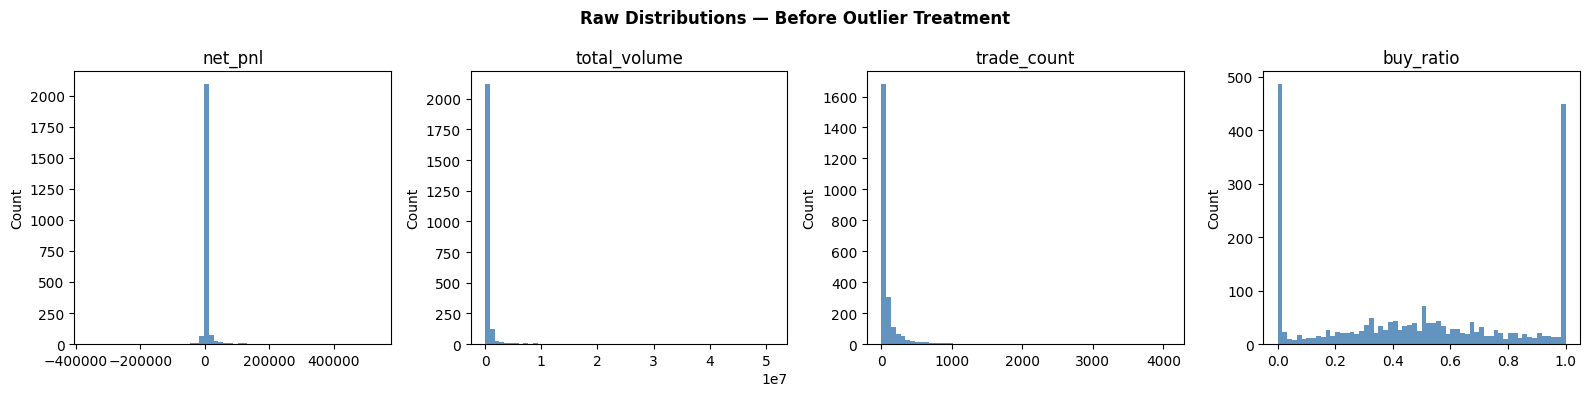

In [6]:
# Visualise distributions 
cols_to_check = ['net_pnl', 'total_volume', 'trade_count', 'buy_ratio']

fig, axes = plt.subplots(1, len(cols_to_check), figsize=(16, 4))
for ax, col in zip(axes, cols_to_check):
    ax.hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set(title=f'{col}', xlabel='', ylabel='Count')
plt.suptitle('Raw Distributions — Before Outlier Treatment', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# IQR-based outlier flagging 
def iqr_bounds(series, multiplier=3.0):
    """Return (lower, upper) IQR bounds."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - multiplier * IQR, Q3 + multiplier * IQR

for col in ['net_pnl', 'total_volume']:
    lo, hi = iqr_bounds(df[col])
    flag_col = f'{col}_outlier'
    df[flag_col] = (df[col] < lo) | (df[col] > hi)
    print(f'{col:20s} → bounds [{lo:,.0f}, {hi:,.0f}]  '
          f'outliers flagged: {df[flag_col].sum()}')

net_pnl              → bounds [-5,222, 6,954]  outliers flagged: 303
total_volume         → bounds [-689,654, 956,297]  outliers flagged: 199


In [8]:
# Winsorise for analysis copies 
def winsorise(series, lower_pct=0.01, upper_pct=0.99):
    lo, hi = series.quantile(lower_pct), series.quantile(upper_pct)
    return series.clip(lower=lo, upper=hi)

df['net_pnl_w']      = winsorise(df['net_pnl'])
df['total_volume_w'] = winsorise(df['total_volume'])

print('Winsorised columns created: net_pnl_w, total_volume_w')

Winsorised columns created: net_pnl_w, total_volume_w


C:\Users\iamli\AppData\Local\Temp\ipykernel_19156\2102529834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fg_label', y=col, data=df, ax=ax,
C:\Users\iamli\AppData\Local\Temp\ipykernel_19156\2102529834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fg_label', y=col, data=df, ax=ax,


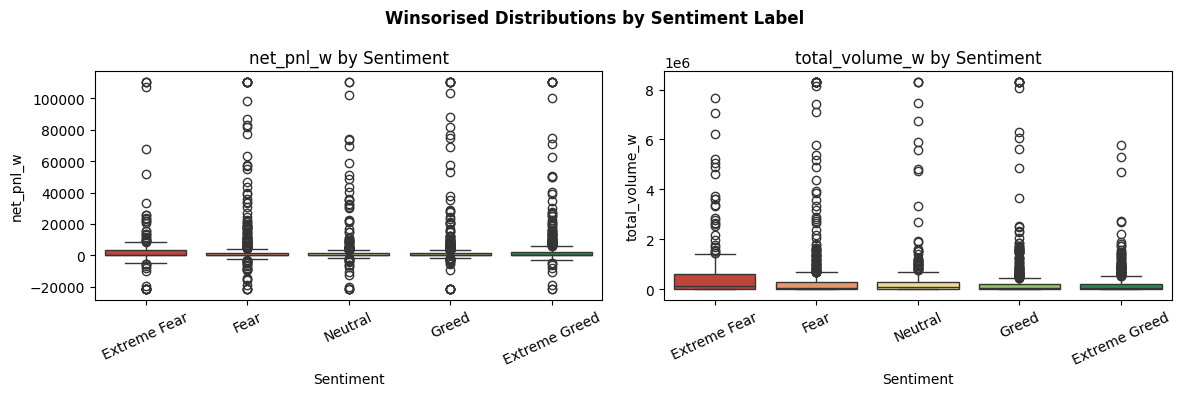

In [9]:
#  Box plots after winsorisation 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['net_pnl_w', 'total_volume_w']):
    sns.boxplot(x='fg_label', y=col, data=df, ax=ax,
                order=sentiment_order,
                palette=['#d73027','#fc8d59','#fee08b','#91cf60','#1a9850'])
    ax.set(title=f'{col} by Sentiment', xlabel='Sentiment', ylabel=col)
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Winsorised Distributions by Sentiment Label', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Work on a date-level sentiment table then merge back
fg_daily = df[['date','fg_value','fg_label']].drop_duplicates('date').sort_values('date').copy()

# Rolling averages
fg_daily['fg_7d_ma']  = fg_daily['fg_value'].rolling(7,  min_periods=1).mean().round(2)
fg_daily['fg_14d_ma'] = fg_daily['fg_value'].rolling(14, min_periods=1).mean().round(2)

# Day-over-day change in sentiment score
fg_daily['fg_delta']  = fg_daily['fg_value'].diff().fillna(0)

# Sentiment momentum: direction of 3-day change
fg_daily['fg_momentum'] = np.sign(fg_daily['fg_value'].diff(3)).fillna(0)

# Extreme zone flags
fg_daily['is_extreme_fear']  = (fg_daily['fg_value'] <= 20).astype(int)
fg_daily['is_extreme_greed'] = (fg_daily['fg_value'] >= 80).astype(int)

# Merge new sentiment features back
df = df.merge(
    fg_daily[['date','fg_7d_ma','fg_14d_ma','fg_delta','fg_momentum',
              'is_extreme_fear','is_extreme_greed']],
    on='date', how='left'
)

print('Sentiment features added ✓')
fg_daily[['date','fg_value','fg_7d_ma','fg_14d_ma','fg_delta','fg_momentum']].tail(10)

Sentiment features added ✓


,date,fg_value,fg_7d_ma,fg_14d_ma,fg_delta,fg_momentum
84,2025-04-22,47.0,35.29,34.71,8.0,1.0
69,2025-04-23,72.0,41.43,38.57,25.0,1.0
70,2025-04-24,63.0,46.14,40.29,-9.0,1.0
71,2025-04-25,60.0,50.00,42.79,-3.0,1.0
72,2025-04-26,65.0,54.71,44.36,5.0,-1.0
73,2025-04-27,61.0,58.14,45.50,-4.0,-1.0
248,2025-04-28,54.0,60.29,47.14,-7.0,-1.0
483,2025-04-29,60.0,62.14,48.71,6.0,-1.0
74,2025-04-30,56.0,59.86,50.64,-4.0,-1.0
75,2025-05-01,53.0,58.43,52.29,-3.0,-1.0


In [11]:
# Win flag per day per account
df['is_win'] = (df['net_pnl'] > 0).astype(int)

# PnL per trade (quality metric)
df['pnl_per_trade'] = (df['net_pnl'] / df['trade_count'].replace(0, np.nan)).round(4)

# Volume per trade (average trade size)
df['avg_trade_size'] = (df['total_volume'] / df['trade_count'].replace(0, np.nan)).round(2)

# Directional bias label
df['bias'] = pd.cut(
    df['buy_ratio'],
    bins=[0, 0.35, 0.65, 1.01],
    labels=['Bearish', 'Neutral', 'Bullish'],
    right=False
)

# Contrarian flag: buying in fear or selling in greed
df['is_contrarian'] = (
    ((df['fg_label'].isin(['Fear','Extreme Fear'])) & (df['buy_ratio'] > 0.6)) |
    ((df['fg_label'].isin(['Greed','Extreme Greed'])) & (df['buy_ratio'] < 0.4))
).astype(int)

# Log volume (compresses skew for regression later)
df['log_volume'] = np.log1p(df['total_volume'])

print('Trader performance features added ✓')
df[['account','date','net_pnl','pnl_per_trade','avg_trade_size',
    'bias','is_contrarian']].head(8)

Trader performance features added ✓


,account,date,net_pnl,pnl_per_trade,avg_trade_size,bias,is_contrarian
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,-167.796055,-0.9480,5089.72,Bearish,1
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,-67.883615,-0.9983,7976.66,Bearish,1
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,-94.937983,-2.3734,23734.50,Bearish,1
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21260.823995,-1771.7353,28186.67,Bullish,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1498.477510,55.4992,17248.15,Neutral,0
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,-132402.679967,-1614.6668,16058.54,Bullish,0
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,-390.921553,-16.9966,48561.69,Bearish,1
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,-175732.230048,-5325.2191,36736.36,Bullish,0


In [12]:
# Quantile-based PnL tiers
df['pnl_tier'] = pd.qcut(
    df['net_pnl_w'],
    q=4,
    labels=['Bottom 25%', 'Lower-Mid', 'Upper-Mid', 'Top 25%'],
    duplicates='drop'
)

print('PnL tier distribution:')
print(df['pnl_tier'].value_counts().sort_index())

PnL tier distribution:
pnl_tier
Bottom 25%    585
Lower-Mid     585
Upper-Mid     585
Top 25%       585
Name: count, dtype: int64


In [13]:
account_profile = (
    df.groupby('account')
    .agg(
        total_pnl       = ('net_pnl',        'sum'),
        total_volume    = ('total_volume',    'sum'),
        total_trades    = ('trade_count',     'sum'),
        active_days     = ('date',            'nunique'),
        win_days        = ('is_win',          'sum'),
        avg_buy_ratio   = ('buy_ratio',       'mean'),
        contrarian_days = ('is_contrarian',   'sum'),
        avg_fg_value    = ('fg_value',        'mean'),
    )
    .reset_index()
)

# Win rate
account_profile['win_rate'] = (
    account_profile['win_days'] / account_profile['active_days']
).round(4)

# PnL per trade overall
account_profile['pnl_per_trade'] = (
    account_profile['total_pnl'] / account_profile['total_trades'].replace(0, np.nan)
).round(4)

# Contrarian rate
account_profile['contrarian_rate'] = (
    account_profile['contrarian_days'] / account_profile['active_days']
).round(4)

# Trader tier based on total PnL
account_profile['trader_tier'] = pd.qcut(
    account_profile['total_pnl'],
    q=3,
    labels=['Losing', 'Break-even', 'Profitable'],
    duplicates='drop'
)

print(f'Unique accounts profiled: {len(account_profile)}')
print(f'\nTrader tier distribution:')
print(account_profile['trader_tier'].value_counts())
account_profile.sort_values('total_pnl', ascending=False).head(10)

Unique accounts profiled: 32

Trader tier distribution:
trader_tier
Losing        11
Profitable    11
Break-even    10
Name: count, dtype: int64


,account,total_pnl,total_volume,total_trades,active_days,win_days,avg_buy_ratio,contrarian_days,avg_fg_value,win_rate,pnl_per_trade,contrarian_rate,trader_tier
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.127387e+06,5.654357e+07,14733,256,120,0.493191,102,57.214844,0.4688,144.3961,0.3984,Profitable
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.592825e+06,6.169726e+07,3818,24,16,0.492171,9,58.541667,0.6667,417.1882,0.3750,Profitable
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.315671e+05,6.803634e+07,21192,28,21,0.524789,14,34.642857,0.7500,43.9584,0.5000,Profitable
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.227277e+05,7.410781e+07,40184,131,104,0.502153,33,50.557252,0.7939,20.4740,0.2519,Profitable
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,7.639979e+05,4.208766e+08,12236,39,21,0.618295,14,44.897436,0.5385,62.4385,0.3590,Profitable
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.697211e+05,3.957295e+07,4356,58,38,0.541426,25,43.310345,0.6552,153.7468,0.4310,Profitable
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.278041e+05,1.147450e+07,1590,19,4,0.422905,8,44.894737,0.2105,269.0592,0.4211,Profitable
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.157949e+05,2.966109e+06,1237,28,7,0.190186,10,48.464286,0.2500,336.1317,0.3571,Profitable
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.765001e+05,2.572950e+07,9893,146,132,0.475421,53,61.609589,0.9041,38.0572,0.3630,Profitable
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.602580e+05,2.962475e+06,1424,65,16,0.372103,45,55.492308,0.2462,252.9902,0.6923,Profitable


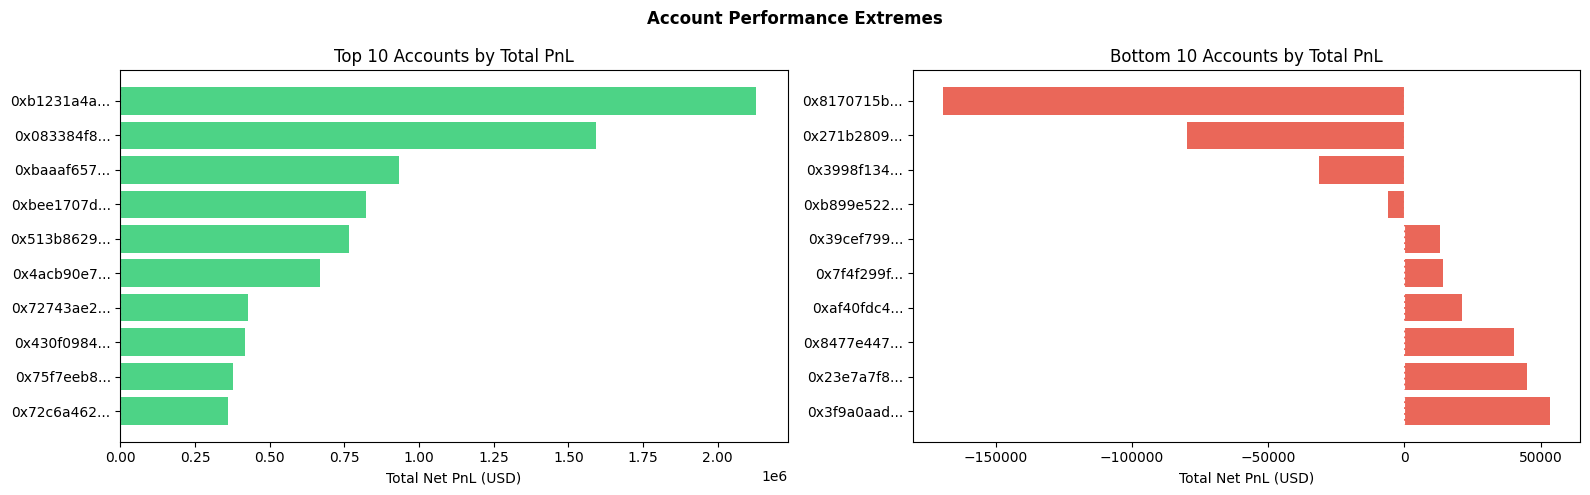

In [14]:
# Top 10 vs Bottom 10 traders 
top10    = account_profile.nlargest(10,  'total_pnl')[['account','total_pnl','win_rate','contrarian_rate']]
bottom10 = account_profile.nsmallest(10, 'total_pnl')[['account','total_pnl','win_rate','contrarian_rate']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title, color in zip(
    axes,
    [top10, bottom10],
    ['Top 10 Accounts by Total PnL', 'Bottom 10 Accounts by Total PnL'],
    ['#2ecc71', '#e74c3c']
):
    short_labels = [a[:10] + '...' for a in data['account']]
    ax.barh(short_labels, data['total_pnl'], color=color, edgecolor='none', alpha=0.85)
    ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
    ax.set(title=title, xlabel='Total Net PnL (USD)')
    ax.invert_yaxis()

plt.suptitle('Account Performance Extremes', fontweight='bold')
plt.tight_layout()
plt.show()

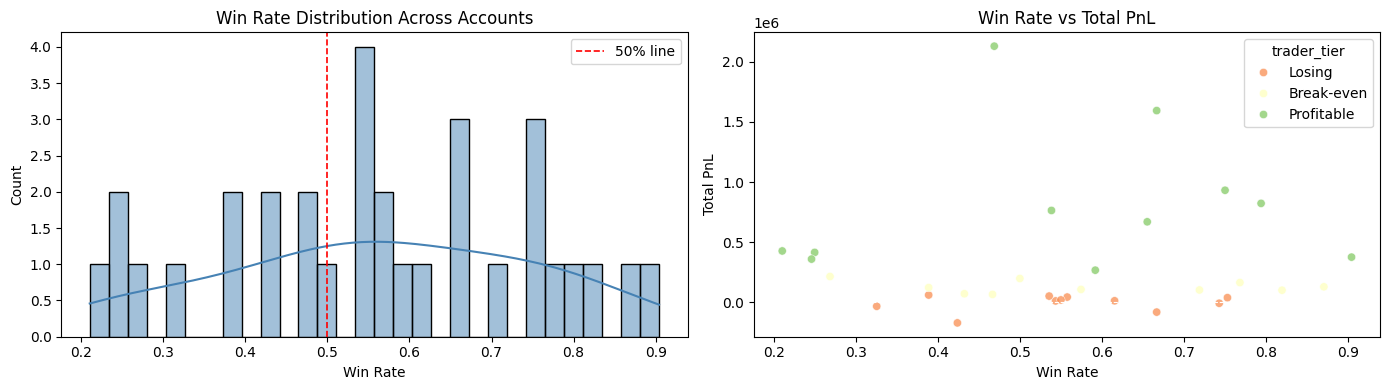

In [15]:
# Win rate distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(account_profile['win_rate'], bins=30, kde=True,
             color='steelblue', ax=axes[0])
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='50% line')
axes[0].set(title='Win Rate Distribution Across Accounts',
            xlabel='Win Rate', ylabel='Count')
axes[0].legend()

sns.scatterplot(data=account_profile, x='win_rate', y='total_pnl',
                hue='trader_tier', palette='RdYlGn', alpha=0.75, ax=axes[1])
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set(title='Win Rate vs Total PnL', xlabel='Win Rate', ylabel='Total PnL')

plt.tight_layout()
plt.show()

In [17]:
# Merge trader tier into main df
df = df.merge(
    account_profile[['account','trader_tier','win_rate',
                      'contrarian_rate','pnl_per_trade']]
    .rename(columns={
        'win_rate'       : 'acct_win_rate',
        'contrarian_rate': 'acct_contrarian_rate',
        'pnl_per_trade'  : 'acct_pnl_per_trade'
    }),
    on='account',
    how='left'
)

print(f'Final shape: {df.shape}')
print(f'Columns    : {df.columns.tolist()}')

Final shape: (2340, 39)
Columns    : ['account', 'date', 'total_pnl', 'total_volume', 'total_fee', 'trade_count', 'buy_count', 'sell_count', 'avg_exec_price', 'coins_traded', 'net_pnl', 'buy_ratio', 'fg_value', 'fg_label', 'net_pnl_outlier', 'total_volume_outlier', 'net_pnl_w', 'total_volume_w', 'fg_7d_ma', 'fg_14d_ma', 'fg_delta', 'fg_momentum', 'is_extreme_fear', 'is_extreme_greed', 'is_win', 'pnl_per_trade', 'avg_trade_size', 'bias', 'is_contrarian', 'log_volume', 'pnl_tier', 'trader_tier_x', 'acct_win_rate_x', 'acct_contrarian_rate_x', 'acct_pnl_per_trade_x', 'trader_tier_y', 'acct_win_rate_y', 'acct_contrarian_rate_y', 'acct_pnl_per_trade_y']


In [18]:
#  Final missing value check 
print('Remaining Missing Values')
missing = df.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].any() else 'None')

Remaining Missing Values
None


In [19]:
#  Final descriptive stats 
df[['net_pnl_w','total_volume_w','trade_count',
    'buy_ratio','fg_value','fg_7d_ma','pnl_per_trade']].describe().round(3)

,net_pnl_w,total_volume_w,trade_count,buy_ratio,fg_value,fg_7d_ma,pnl_per_trade
count,2340.000,2340.000,2340.000,2340.000,2340.000,2340.000,2340.000
mean,3749.681,392406.613,90.264,0.489,54.852,54.970,99.020
std,15109.551,1127045.025,214.651,0.364,20.619,19.717,890.419
min,-21681.358,0.614,1.000,0.000,10.000,20.000,-18620.207
25%,-3.340,15753.868,9.000,0.143,34.000,35.430,-0.263
50%,178.439,69168.265,29.000,0.486,55.000,55.785,4.585
75%,1736.084,250889.740,80.000,0.833,74.000,73.430,37.351
max,110634.307,8313628.855,4083.000,1.000,94.000,87.860,14998.075


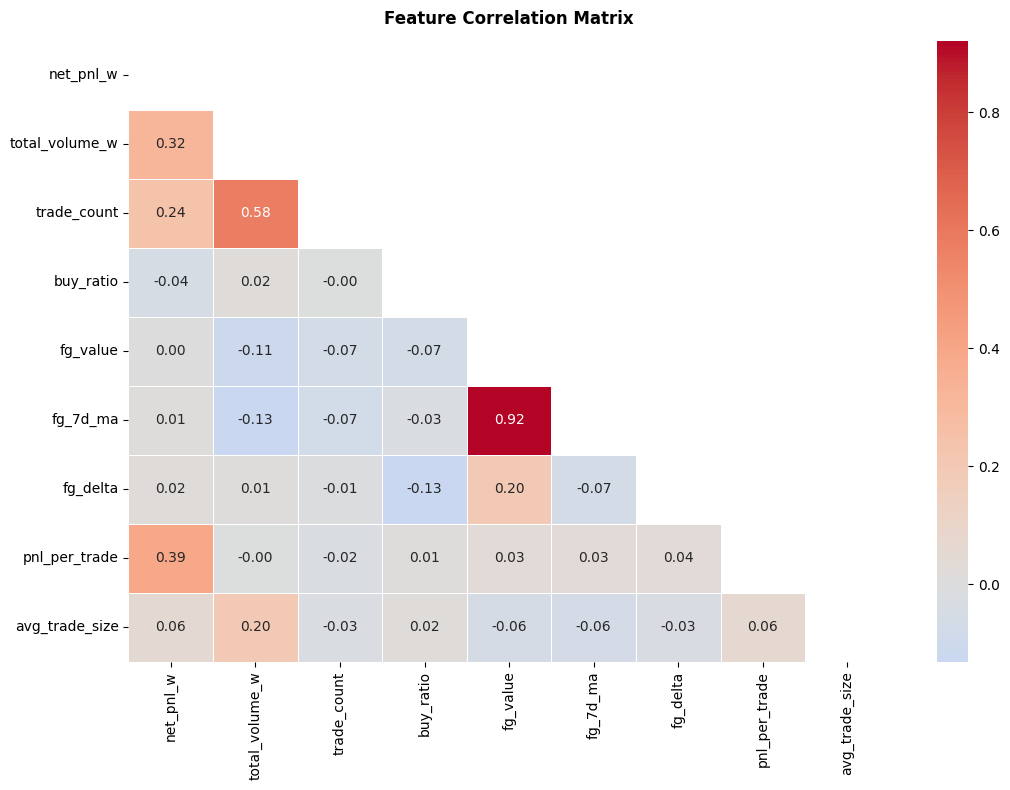

In [20]:
#  Correlation heatmap — numeric features 
num_cols = ['net_pnl_w','total_volume_w','trade_count','buy_ratio',
            'fg_value','fg_7d_ma','fg_delta','pnl_per_trade','avg_trade_size']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [21]:
df.to_csv(OUTPUT_FILE, index=False)
account_profile.to_csv(
    os.path.join(PROCESSED_DIR, 'account_profiles.csv'), index=False
)

print('Saved to data/processed/')

Saved to data/processed/
